<a href="https://colab.research.google.com/github/smaranikaduttapattanaik/self-pruning-neural-network/blob/main/self_pruning_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Model Design Strategy

You will replace standard Linear layers with:

PrunableLinear = Weight ⊙ Sigmoid(GateScores)

So the effective weight becomes:

W_eff = W * σ(G)

This ensures:

Differentiability ✅
Learnable pruning ✅
End-to-end training ✅
2. Key Components to Build
(A) Custom Layer
Parameters:
weight (normal)
bias (optional)
gate_scores (same shape as weight)
Forward:
gates = sigmoid(gate_scores)
pruned_weight = weight * gates
Apply F.linear
(B) Network Architecture

Keep it simple (CIFAR-10 baseline):

Flatten → PrunableLinear → ReLU → PrunableLinear → ReLU → PrunableLinear → Output

You can later extend to ConvNet, but MLP is enough for this case study.

(C) Sparsity Loss

Core idea:

SparsityLoss = sum of all gate values
TotalLoss = CrossEntropy + λ * SparsityLoss

Why this works:

L1 pushes values → 0
Sigmoid ensures [0,1]
So many gates collapse → 0
(D) Training Loop

Each iteration:

Forward pass
Compute:
Classification loss
Sparsity loss
Combine using λ
Backprop
(E) Evaluation Metrics

After training:

1. Sparsity Level
% of gates < threshold (1e-2)
2. Test Accuracy
3. Gate Distribution Plot
Expect:
Spike near 0
Some near 1
(F) Experiments (IMPORTANT)

Run for:

λ = [1e-5, 1e-4, 1e-3]

Observe:

Low λ → high accuracy, low pruning
High λ → high sparsity, lower accuracy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


# Prunable Linear Layer


PrunableLinear = Weight ⊙ Sigmoid(GateScores)

So the effective weight becomes:

W_eff = W * σ(G)

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (learnable)
        # self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))
        # init gatess to promote self pruning
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 3)

    def forward(self, x):
        # gates = torch.sigmoid(self.gate_scores)
        # temperature scaling - for sharper pruning
        # gates = torch.sigmoid(self.gate_scores * 5 )
        gates = torch.sigmoid(self.gate_scores)
        # gates = torch.clamp((self.gate_scores + 1) / 2, 0, 1)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

In [ ]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Sparsity Loss Function

In [ ]:
def compute_sparsity_loss(model):
    sparsity_loss = 0.0
    total_params = 0   # ✅ initialize

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            sparsity_loss += gates.sum()
            total_params += gates.numel()   # ✅ correct function call

    # sparsity_loss = sparsity_loss / total_params  # normalize
    return sparsity_loss

# Training Function

In [ ]:
def train_model(lambda_val, epochs=5):
    model = PrunableMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            loss = cls_loss + lambda_val * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

    return model

 # Evaluation Metrics

In [ ]:
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    # Sparsity calculation
    total_weights = 0
    pruned_weights = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total_weights += gates.numel()
            pruned_weights += (gates < 1e-2).sum().item()

    sparsity = 100 * pruned_weights / total_weights

    return accuracy, sparsity

## running experiments

30 epochs

In [ ]:
# lambdas = [1e-5, 1e-4, 1e-3]

# increasing lambda lambdas = [1e-3, 1e-2, 1e-1]
# lambdas = [1e-3, 1e-2, 1e-1]
lambdas = [1e-3, 5e-3, 1e-2, 5e-2]


results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam, epochs=30)
    acc, sparsity = evaluate(model)

    results.append((lam, acc, sparsity))

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}, Sparsity: {sparsity:.2f}")


Training with lambda = 0.001
Epoch 1, Loss: 769.2664
Epoch 2, Loss: 666.4176
Epoch 3, Loss: 617.9097
Epoch 4, Loss: 585.6969
Epoch 5, Loss: 562.4240
Epoch 6, Loss: 541.7626
Epoch 7, Loss: 523.3170
Epoch 8, Loss: 505.7902
Epoch 9, Loss: 488.1469
Epoch 10, Loss: 472.4072
Epoch 11, Loss: 457.0805
Epoch 12, Loss: 442.7111
Epoch 13, Loss: 429.3508
Epoch 14, Loss: 414.5786
Epoch 15, Loss: 402.0020
Epoch 16, Loss: 390.0303
Epoch 17, Loss: 376.4942
Epoch 18, Loss: 364.7004
Epoch 19, Loss: 351.8017
Epoch 20, Loss: 340.4953
Epoch 21, Loss: 328.4524
Epoch 22, Loss: 317.6675
Epoch 23, Loss: 304.5324
Epoch 24, Loss: 293.9261
Epoch 25, Loss: 282.2732
Epoch 26, Loss: 272.5676
Epoch 27, Loss: 260.1279
Epoch 28, Loss: 249.9220
Epoch 29, Loss: 238.6092
Epoch 30, Loss: 229.0257
Lambda: 0.001, Accuracy: 54.47, Sparsity: 5.54

Training with lambda = 0.005
Epoch 1, Loss: 770.4815
Epoch 2, Loss: 662.7882
Epoch 3, Loss: 616.7447
Epoch 4, Loss: 586.4334
Epoch 5, Loss: 563.8454
Epoch 6, Loss: 543.4241
Epoch 7,


Final Results:
Lambda | Accuracy | Sparsity (%)
0.001 | 54.47 | 5.54
0.005 | 53.70 | 5.53
0.01 | 53.46 | 5.59
0.05 | 53.17 | 5.86


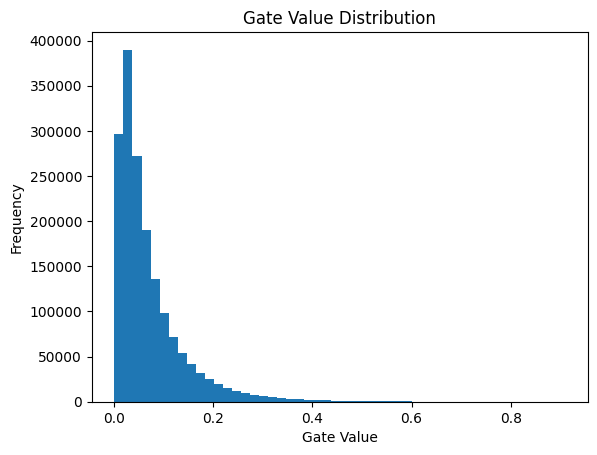

In [ ]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity (%)")

for r in results:
    print(f"{r[0]} | {r[1]:.2f} | {r[2]:.2f}")


def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

# Plot for last model
plot_gate_distribution(model)

In [ ]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity (%)")

for r in results:
    print(f"{r[0]} | {r[1]:.2f} | {r[2]:.2f}")


Final Results:
Lambda | Accuracy | Sparsity (%)
0.001 | 52.32 | 5.78
0.01 | 50.21 | 9.36
0.1 | 41.52 | 35.42


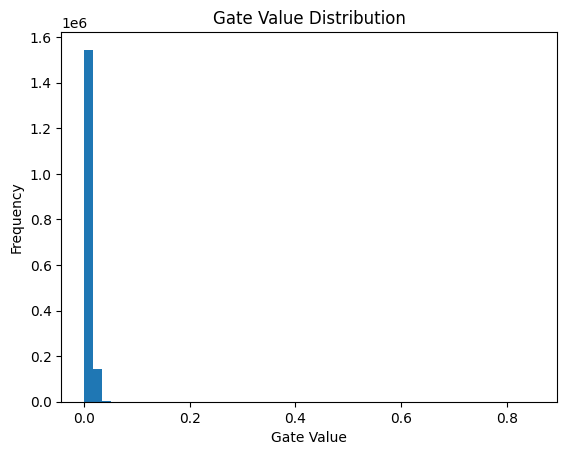

In [ ]:
def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

# Plot for last model
plot_gate_distribution(model)

### trainign for 30 epochs
Total Loss ≈ Classification Loss >> λ × Sparsity Loss
- so fixing strategy
- Increase λ aggressively
- Initialize gates to favor pruning
- Normalize Sparsity Loss (CRITICAL)
- Use Temperature Scaling (sharper pruning)

In [ ]:
# lambdas = [1e-5, 1e-4, 1e-3]

# increasing lambda lambdas = [1e-3, 1e-2, 1e-1]
# lambdas = [1e-3, 1e-2, 1e-1]
# lambdas = [1e-3, 5e-3, 1e-2, 5e-2]

lambdas = [0.01, 0.1]
epochs = 10
results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam, epochs=epochs)
    acc, sparsity = evaluate(model)

    results.append((lam, acc, sparsity))

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}, Sparsity: {sparsity:.2f}")


Training with lambda = 0.01
Epoch 1, Loss: 394984.8740
Epoch 2, Loss: 290344.8395
Epoch 3, Loss: 219427.3784
Epoch 4, Loss: 169653.2897
Epoch 5, Loss: 133637.4052
Epoch 6, Loss: 106876.5056
Epoch 7, Loss: 86533.9979
Epoch 8, Loss: 70768.7805
Epoch 9, Loss: 58350.9168
Epoch 10, Loss: 48436.2934
Lambda: 0.01, Accuracy: 40.30, Sparsity: 81.14

Training with lambda = 0.1
Epoch 1, Loss: 3941366.4805
Epoch 2, Loss: 2895887.5137
Epoch 3, Loss: 2187005.4688
Epoch 4, Loss: 1689379.1914
Epoch 5, Loss: 1329255.1760
Epoch 6, Loss: 1061643.4709
Epoch 7, Loss: 858199.0751
Epoch 8, Loss: 700518.4680
Epoch 9, Loss: 576308.3331
Epoch 10, Loss: 477131.7571
Lambda: 0.1, Accuracy: 34.50, Sparsity: 81.21



Final Results:
Lambda | Accuracy | Sparsity (%)
0.01 | 40.30 | 81.14
0.1 | 34.50 | 81.21


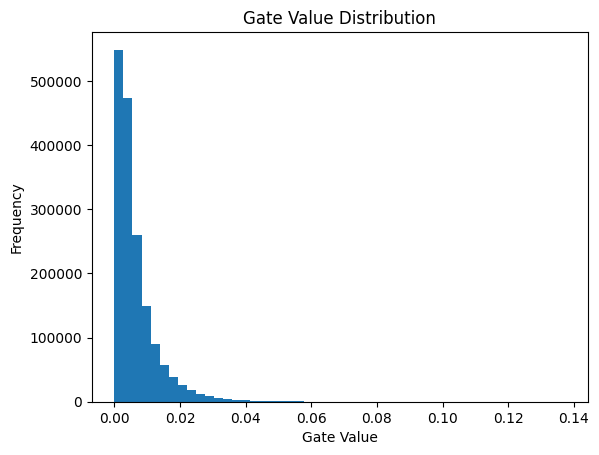

In [ ]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity (%)")

for r in results:
    print(f"{r[0]} | {r[1]:.2f} | {r[2]:.2f}")


def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

# Plot for last model
plot_gate_distribution(model)